### Setup - Numerical Data(Titanic Age)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv('train.csv', usecols=['Age','Fare','Survived'])

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing %:")
print((df.isnull().mean() * 100).round(2))

Shape: (891, 3)

First 5 rows:
   Survived   Age     Fare
0         0  22.0   7.2500
1         1  38.0  71.2833
2         1  26.0   7.9250
3         1  35.0  53.1000
4         0  35.0   8.0500

Missing %:
Survived     0.00
Age         19.87
Fare         0.00
dtype: float64


### Train-Test-Split

In [2]:
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=2
)

print("X_train shape:", X_train.shape)
print("Missing in X_train Age:", X_train['Age'].isnull().sum())
print("Missing in X_test Age :", X_test['Age'].isnull().sum())

X_train shape: (712, 2)
Missing in X_train Age: 148
Missing in X_test Age : 29


In [6]:
print("X_train head : ")
print(X_train.head())
print("X_train tail : ")
print(X_train.tail())
print("X_test head : ")
print(X_test.head())
print("X_test tail : ")
print(X_test.tail())

X_train head : 
      Age     Fare  Age_imputed
30   40.0  27.7208         40.0
10    4.0  16.7000          4.0
873  47.0   9.0000         47.0
182   9.0  31.3875          9.0
876  20.0   9.8458         20.0
X_train tail : 
      Age      Fare  Age_imputed
534  30.0    8.6625         30.0
584   NaN    8.7125          NaN
493  71.0   49.5042         71.0
527   NaN  221.7792          NaN
168   NaN   25.9250          NaN
X_test head : 
      Age     Fare  Age_imputed
707  42.0  26.2875         42.0
37   21.0   8.0500         21.0
615  24.0  65.0000         24.0
169  28.0  56.4958         28.0
68   17.0   7.9250         17.0
X_test tail : 
      Age     Fare  Age_imputed
89   24.0   8.0500         24.0
80   22.0   9.0000         22.0
846   NaN  69.5500          NaN
870  26.0   7.8958         26.0
251  29.0  10.4625         29.0


In [17]:
# STEP 1: how many values are missing?
n_missing = X_train['Age'].isnull().sum()
print(f"Missing count: {n_missing}")

# STEP 2: get all existing (non-null) values
existing_values = X_train['Age'].dropna()
print(f"Existing values count: {len(existing_values)}")

# STEP 3: randomly sample n_missing values from existing
# replace=True → same value can be picked multiple times
random_samples = existing_values.sample(
    n_missing,
    random_state=42   # for reproducibility
)
print(f"\nRandom samples picked ({n_missing} values):")
print(random_samples.values[:20], "...")

# STEP 4: these samples fill the missing slots
print(f"\nSample range: {random_samples.min()} to {random_samples.max()}")
print(f"Real Age range: {existing_values.min()} to {existing_values.max()}")

Missing count: 148
Existing values count: 564

Random samples picked (148 values):
[22. 18. 38. 40. 52. 23. 32. 16. 27.  9. 26. 45. 17. 30. 26. 25. 24. 30.
 36. 24.] ...

Sample range: 0.75 to 71.0
Real Age range: 0.42 to 71.0


### Applying Random Sample Imputation - Numerical

In [18]:
X_train = X_train.copy()
X_test  = X_test.copy()

# STEP 1: create imputed column as copy of original
# (non-missing rows stay the same)
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed']  = X_test['Age']

# STEP 2: fill missing in TRAIN
# → randomly sample from train's existing values
X_train.loc[
    X_train['Age_imputed'].isnull(),   # where Age is NaN
    'Age_imputed'                       # fill this column
] = X_train['Age'].dropna().sample(
    X_train['Age'].isnull().sum(),      # sample exactly n_missing values
    random_state=42
).values

# STEP 3: fill missing in TEST
# → sample from TRAIN's values (not test!)
# → same rule as fitting on train only
X_test.loc[
    X_test['Age_imputed'].isnull(),    # where test Age is NaN
    'Age_imputed'
] = X_train['Age'].dropna().sample(    # ← from TRAIN not TEST
    X_test['Age'].isnull().sum(),
    random_state=42
).values

print("Before and after:")
print(X_train[['Age','Age_imputed']].head(10))
print(f"\nMissing in Age         : {X_train['Age'].isnull().sum()}")
print(f"Missing in Age_imputed : {X_train['Age_imputed'].isnull().sum()}")

Before and after:
      Age  Age_imputed
30   40.0         40.0
10    4.0          4.0
873  47.0         47.0
182   9.0          9.0
876  20.0         20.0
213  30.0         30.0
157  30.0         30.0
780  13.0         13.0
572  36.0         36.0
77    NaN         22.0

Missing in Age         : 148
Missing in Age_imputed : 0


### Check Variance

In [19]:
print("=" * 50)
print("VARIANCE COMPARISON")
print("=" * 50)

orig_var   = X_train['Age'].var()
imputed_var = X_train['Age_imputed'].var()

print(f"\nOriginal Age variance   : {orig_var:.2f}")
print(f"After random imputation : {imputed_var:.2f}")
print(f"Change                  : {((imputed_var/orig_var)-1)*100:+.2f}%")

print("\nCompare all methods:")
mean_imp   = X_train['Age'].fillna(X_train['Age'].mean())
median_imp = X_train['Age'].fillna(X_train['Age'].median())

print(f"  Original variance        : {orig_var:.2f}")
print(f"  Mean imputation variance : {mean_imp.var():.2f}  ({((mean_imp.var()/orig_var)-1)*100:+.1f}%)")
print(f"  Median imputation var    : {median_imp.var():.2f}  ({((median_imp.var()/orig_var)-1)*100:+.1f}%)")
print(f"  Random sample variance   : {imputed_var:.2f}  ({((imputed_var/orig_var)-1)*100:+.1f}%)  ✅ best!")

VARIANCE COMPARISON

Original Age variance   : 204.35
After random imputation : 200.03
Change                  : -2.11%

Compare all methods:
  Original variance        : 204.35
  Mean imputation variance : 161.81  (-20.8%)
  Median imputation var    : 161.99  (-20.7%)
  Random sample variance   : 200.03  (-2.1%)  ✅ best!


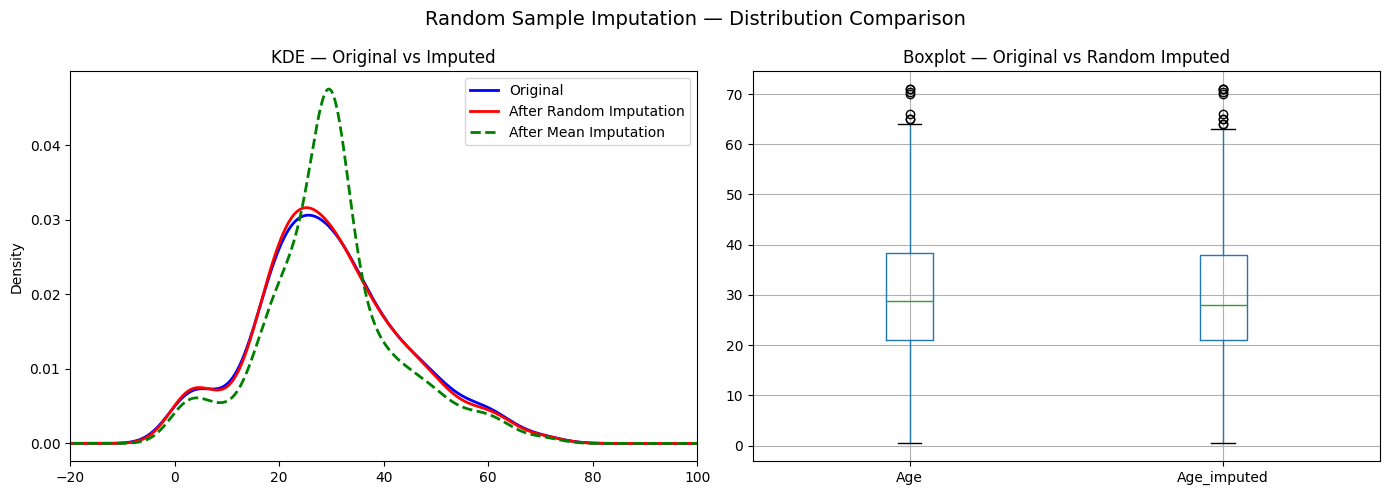

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Random Sample Imputation — Distribution Comparison", fontsize=14)

# KDE comparison
X_train['Age'].plot.kde(
    ax=axes[0], color='blue', label='Original', linewidth=2
)
X_train['Age_imputed'].plot.kde(
    ax=axes[0], color='red', label='After Random Imputation', linewidth=2
)
mean_imp.plot.kde(
    ax=axes[0], color='green', label='After Mean Imputation',
    linewidth=2, linestyle='--'
)
axes[0].set_title("KDE — Original vs Imputed")
axes[0].legend()
axes[0].set_xlim(-20, 100)

# Boxplot comparison
X_train[['Age','Age_imputed']].boxplot(ax=axes[1])
axes[1].set_title("Boxplot — Original vs Random Imputed")

plt.tight_layout()
plt.show()

### Covariance Checking

In [21]:
cov = X_train[['Fare','Age','Age_imputed']].cov()
print("Covariance matrix:")
print(cov.round(2))

print(f"\nFare vs Age (original)       : {X_train['Fare'].cov(X_train['Age']):.2f}")
print(f"Fare vs Age_imputed (random) : {X_train['Fare'].cov(X_train['Age_imputed']):.2f}")

Covariance matrix:
                Fare     Age  Age_imputed
Fare         2368.25   71.51        53.26
Age            71.51  204.35       204.35
Age_imputed    53.26  204.35       200.03

Fare vs Age (original)       : 71.51
Fare vs Age_imputed (random) : 53.26


### Categorical Random Sample Imputation

In [22]:
data = pd.read_csv('house-train.csv',
                   usecols=['GarageQual','FireplaceQu','SalePrice'])

X = data
y = data['SalePrice']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X, y, test_size=0.2, random_state=2
)

X_train_h = X_train_h.copy()
X_test_h  = X_test_h.copy()

print("Missing in X_train:")
print(X_train_h.isnull().sum())

Missing in X_train:
FireplaceQu    557
GarageQual      65
SalePrice        0
dtype: int64


In [23]:
# apply random sample imputation to categorical columns

for col in ['GarageQual', 'FireplaceQu']:

    # create imputed column
    X_train_h[f'{col}_imputed'] = X_train_h[col]
    X_test_h[f'{col}_imputed']  = X_test_h[col]

    # fill train missing
    n_missing_train = X_train_h[col].isnull().sum()
    X_train_h.loc[
        X_train_h[f'{col}_imputed'].isnull(),
        f'{col}_imputed'
    ] = X_train_h[col].dropna().sample(
        n_missing_train,
        random_state=42
    ).values

    # fill test missing (from train values)
    n_missing_test = X_test_h[col].isnull().sum()
    X_test_h.loc[
        X_test_h[f'{col}_imputed'].isnull(),
        f'{col}_imputed'
    ] = X_train_h[col].dropna().sample(
        n_missing_test,
        random_state=42
    ).values

    print(f"\n{col} — missing remaining: {X_train_h[f'{col}_imputed'].isnull().sum()}")


GarageQual — missing remaining: 0

FireplaceQu — missing remaining: 0


In [24]:
for col in ['GarageQual', 'FireplaceQu']:
    temp = pd.concat([
        # proportion in original (excluding NaN)
        X_train_h[col].value_counts(normalize=True),
        # proportion after imputation
        X_train_h[f'{col}_imputed'].value_counts(normalize=True)
    ], axis=1)

    temp.columns   = ['Original %', 'After Imputation %']
    temp           = temp.mul(100).round(2)
    temp['Diff %'] = (temp['After Imputation %'] - temp['Original %']).round(2)

    print(f"\n{col} category proportions:")
    print(temp)
    print(f"Max shift: {temp['Diff %'].abs().max():.2f}%")


GarageQual category proportions:
    Original %  After Imputation %  Diff %
TA       95.10               95.21    0.11
Fa        3.72                3.68   -0.04
Gd        1.00                0.94   -0.06
Po        0.09                0.09    0.00
Ex        0.09                0.09    0.00
Max shift: 0.11%

FireplaceQu category proportions:
    Original %  After Imputation %  Diff %
Gd       49.43               50.00    0.57
TA       41.24               40.67   -0.57
Fa        4.09                4.02   -0.07
Po        2.78                2.83    0.05
Ex        2.45                2.48    0.03
Max shift: 0.57%


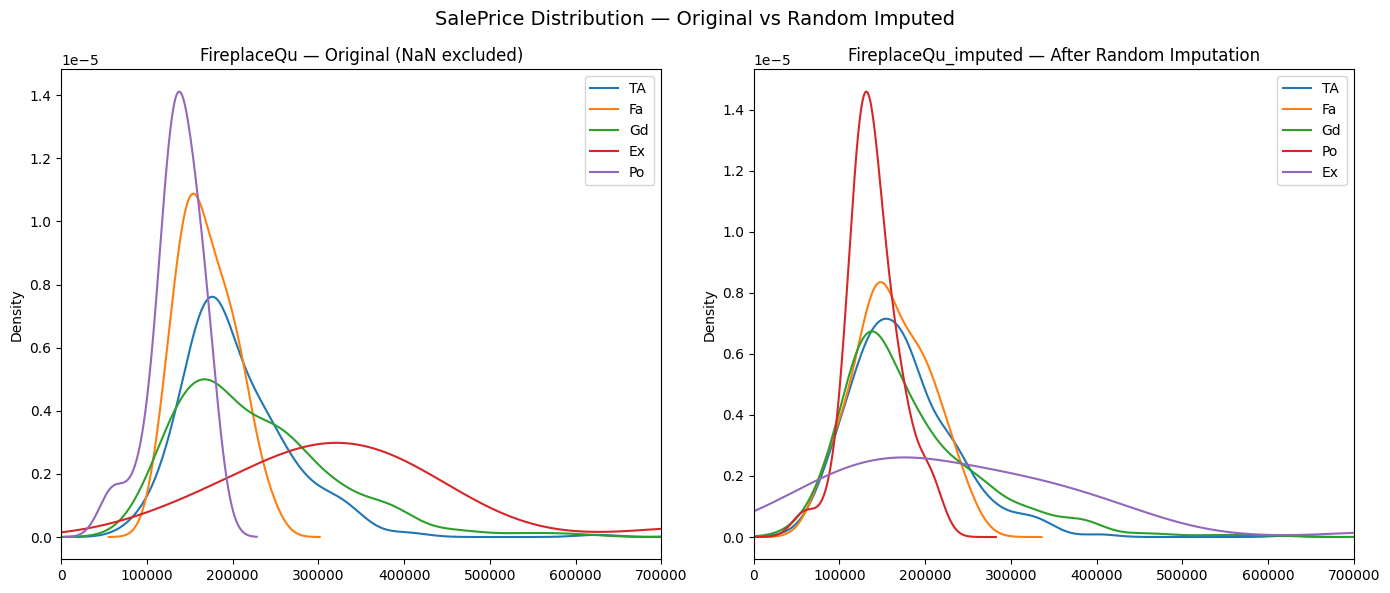

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("SalePrice Distribution — Original vs Random Imputed", fontsize=14)

# original FireplaceQu
for category in X_train_h['FireplaceQu'].dropna().unique():
    subset = X_train_h[X_train_h['FireplaceQu'] == category]
    subset['SalePrice'].plot.kde(ax=axes[0], label=category)
axes[0].set_title("FireplaceQu — Original (NaN excluded)")
axes[0].legend()
axes[0].set_xlim(0, 700000)

# after imputation
for category in X_train_h['FireplaceQu_imputed'].unique():
    subset = X_train_h[X_train_h['FireplaceQu_imputed'] == category]
    subset['SalePrice'].plot.kde(ax=axes[1], label=category)
axes[1].set_title("FireplaceQu_imputed — After Random Imputation")
axes[1].legend()
axes[1].set_xlim(0, 700000)

plt.tight_layout()
plt.show()